# Tratamento dos dados

## Une as tabelas

In [54]:
import pandas as pd

articles_df = pd.read_csv('input/articles.csv')
data_extraction_df = pd.read_csv('input/data_extraction.csv').rename(columns={'article': 'title'})

articles_df['year'] = pd.to_numeric(articles_df['year'], errors='coerce')
data_extraction_df['Ano'] = pd.to_numeric(data_extraction_df['Ano'], errors='coerce')

merged_df = pd.merge(articles_df, data_extraction_df, on='title', how='outer')
merged_df['year'] = merged_df['year'].fillna(merged_df['Ano'])
merged_df = merged_df.drop(columns=['Ano']).rename(columns={'year': 'ano'})

ordered_cols = ['title', 'ano'] + [c for c in merged_df.columns if c not in ['title', 'ano']]
merged_df = merged_df[ordered_cols]

output_csv = 'merged_articles_data.csv'
merged_df.to_csv(output_csv, index=False)

print('Arquivo criado com sucesso!')
print(f'Total de registros: {len(merged_df)}')

Arquivo criado com sucesso!
Total de registros: 1516


## Corrige termos

In [55]:
import pandas as pd

input_csv = 'merged_articles_data.csv'
output_csv = 'transformed_data.csv'

translation_dict = {
    'Embutido': 'Embedded',
    'Projetor superior': 'Front-Projected',
    'Projetor inferior': 'Rear-Projected',
    'Caneta': 'Pen',
    'Ondas sonoras': 'Sound-Based',
    'Sensor infravermelho': 'Sensor-Assisted-Vision-Based',
    'Tokens tangíveis': 'Tangible-Tokens',
    'Toque': 'Electrical-Based',
    'Visão computacional': 'Vision-Based',
    'Incomplete works, posters, summaries': 'Incomplete works, posters, summaries, etc',
    'Interfaces with only mouse/keyboard interaction': 'Interfaces without direct interaction',
    'The digital tabletop interface was not tangible': 'Study was not about digital tabletops',
}

def translate_terms(text):
    if pd.isna(text):
        return text
    for pt, en in translation_dict.items():
        text = text.replace(pt, en)
    return text

df = pd.read_csv(input_csv)
df['Tecnologia do display'] = df['Tecnologia do display'].apply(translate_terms)
df['Tecnologia do input'] = df['Tecnologia do input'].apply(translate_terms)
df['selection_criteria'] = df['selection_criteria'].apply(translate_terms)

df.to_csv(output_csv, index=False)

print('Transformação concluída! Resultado salvo em ' + output_csv)

Transformação concluída! Resultado salvo em transformed_data.csv


## Desmarca inputs e interações redundantes

In [56]:
import pandas as pd

df = pd.read_csv('transformed_data.csv')
accepted_df = df[df['status'] == 'Accepted'].copy()
accepted_df.to_csv('accepted_data.csv', index=False)
print("Criado accepted_data.csv com as linhas 'Accepted'.")

adapted_df = accepted_df.copy()

def split_values(text):
    if not isinstance(text, str):
        return text
    return [v.strip() for v in text.split(',') if v.strip()]

def clean_input_tech(text):
    values = split_values(text)
    if not isinstance(values, list):
        return values

    if 'Sensor-Assisted-Vision-Based' in values and 'Vision-Based' in values:
        values = [v for v in values if v != 'Vision-Based']

    values = ['Pure-Vision-Based' if v == 'Vision-Based' else v for v in values]
    return ', '.join(sorted(set(values)))

def clean_interaction_type(text):
    values = split_values(text)
    if not isinstance(values, list):
        return values

    if 'Multi-touch' in values and 'Touch' in values:
        values = [v for v in values if v != 'Touch']

    return ', '.join(sorted(set(values)))

def clean_collaboration(text):
    values = split_values(text)
    if not isinstance(values, list):
        return values

    if 'Colaboração presencial' in values and 'Usuário Único' in values:
        values = [v for v in values if v != 'Usuário Único']

    if 'Colaboração presencial' in values and 'Colaboração remota' in values:
        values = [v for v in values if v != 'Colaboração presencial']

    return ', '.join(sorted(set(values)))

adapted_df['Tecnologia do input'] = adapted_df['Tecnologia do input'].astype(str).apply(clean_input_tech)
adapted_df['Tipo de interação'] = adapted_df['Tipo de interação'].astype(str).apply(clean_interaction_type)
adapted_df['Suporte à colaboração'] = adapted_df['Suporte à colaboração'].astype(str).apply(clean_collaboration)

adapted_df.to_csv('accepted_data_adapted.csv', index=False)
print('Criado accepted_data_adapted.csv com os filtros aplicados.')

Criado accepted_data.csv com as linhas 'Accepted'.
Criado accepted_data_adapted.csv com os filtros aplicados.


## Tabela aceitos por base de dados


In [57]:
import pandas as pd

df = pd.read_csv('transformed_data.csv')
summary = df.groupby('source')['status'].value_counts().unstack(fill_value=0)

summary['Aceitos'] = summary.get('Accepted', 0)
summary['Rejeitados'] = summary.get('Rejected', 0) + summary.get('Duplicated', 0) + summary.get('Unclassified', 0)
summary['Resultados'] = summary['Aceitos'] + summary['Rejeitados']

final_table = summary[['Resultados', 'Aceitos', 'Rejeitados']].reset_index()
final_table.columns = ['Base de dados', 'Resultados', 'Aceitos', 'Rejeitados']

total_row = pd.DataFrame([{
    'Base de dados': 'Total',
    'Resultados': final_table['Resultados'].sum(),
    'Aceitos': final_table['Aceitos'].sum(),
    'Rejeitados': final_table['Rejeitados'].sum(),
}])

final_table = pd.concat([final_table, total_row], ignore_index=True)
print(final_table)

          Base de dados  Resultados  Aceitos  Rejeitados
0   ACM Digital Library         707      275         432
1  IEEE Digital Library         189       88         101
2        Science@Direct          91       30          61
3                Scopus         178       54         124
4         Springer Link         350      109         241
5                 Total        1515      556         959


## Adiciona citações na tabela

In [58]:
import json
import os
import time
import numpy as np
import pandas as pd
from habanero import Crossref

# Ajuste aqui se quiser identificar seu contato para a API (recomendado pela CrossRef)
MAILTO = None  # exemplo: "seu-email@dominio.com"

input_path = "../full_table_tex/accepted_articles.csv"
output_path = "../full_table_tex/accepted_articles.csv"
cache_path = "../full_table_tex/crossref_citations_cache.json"


def normalize_doi(value):
    if pd.isna(value):
        return None
    doi = str(value).strip()
    if not doi:
        return None
    return doi


def load_cache(path):
    if not os.path.exists(path):
        return {}
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        return data if isinstance(data, dict) else {}
    except Exception:
        return {}


def save_cache(path, data):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=True, indent=2)


# Carregar tabela
_df = pd.read_csv(input_path)

# Garantir coluna de saída
if "citations" not in _df.columns:
    _df["citations"] = np.nan

# Filtrar DOIs válidos
_df["_doi_norm"] = _df["doi"].apply(normalize_doi)
valid_doi_mask = _df["_doi_norm"].notna()
unique_dois = sorted(_df.loc[valid_doi_mask, "_doi_norm"].unique())

print(f"Linhas totais: {len(_df)}")
print(f"Linhas com DOI válido: {valid_doi_mask.sum()}")
print(f"DOIs únicos para consulta: {len(unique_dois)}")

cache = load_cache(cache_path)
cached_count = sum(1 for doi in unique_dois if doi in cache)
print(f"DOIs já em cache: {cached_count}")

cr = Crossref(mailto=MAILTO) if MAILTO else Crossref()
errors = []

for idx, doi in enumerate(unique_dois, start=1):
    if doi not in cache:
        try:
            response = cr.works(ids=doi)
            citations = response.get("message", {}).get("is-referenced-by-count")
            cache[doi] = int(citations) if citations is not None else None
        except Exception as exc:
            cache[doi] = None
            errors.append((doi, str(exc)))

        # Evita sobrecarregar a API
        time.sleep(0.1)

    if idx % 25 == 0 or idx == len(unique_dois):
        print(f"Processados {idx}/{len(unique_dois)} DOIs...")
        save_cache(cache_path, cache)

# Salva cache final
save_cache(cache_path, cache)

# Aplicar resultado em todas as linhas com DOI
mapped = _df.loc[valid_doi_mask, "_doi_norm"].map(cache)
mapped = pd.to_numeric(mapped, errors="coerce")

_df["citations"] = pd.to_numeric(_df["citations"], errors="coerce")
_df.loc[valid_doi_mask, "citations"] = mapped

# Usa inteiro anulável para manter coluna de citações limpa
_df["citations"] = _df["citations"].round().astype("Int64")

# Limpeza e persistência
_df = _df.drop(columns=["_doi_norm"])
_df.to_csv(output_path, index=False)

filled = _df.loc[valid_doi_mask, "citations"].notna().sum()
print(f"Citações preenchidas: {filled}/{valid_doi_mask.sum()} linhas com DOI")
print(f"Falhas de consulta nesta execução: {len(errors)}")

if errors:
    print("Exemplos de falha (até 5):")
    for doi, err in errors[:5]:
        print(f"- {doi} -> {err}")

print(f"Arquivo atualizado: {output_path}")
print(f"Cache salvo em: {cache_path}")

Linhas totais: 556
Linhas com DOI válido: 546
DOIs únicos para consulta: 544
DOIs já em cache: 544
Processados 25/544 DOIs...
Processados 50/544 DOIs...
Processados 75/544 DOIs...
Processados 100/544 DOIs...
Processados 125/544 DOIs...
Processados 150/544 DOIs...
Processados 175/544 DOIs...
Processados 200/544 DOIs...
Processados 225/544 DOIs...
Processados 250/544 DOIs...
Processados 275/544 DOIs...
Processados 300/544 DOIs...
Processados 325/544 DOIs...
Processados 350/544 DOIs...
Processados 375/544 DOIs...
Processados 400/544 DOIs...
Processados 425/544 DOIs...
Processados 450/544 DOIs...
Processados 475/544 DOIs...
Processados 500/544 DOIs...
Processados 525/544 DOIs...
Processados 544/544 DOIs...
Citações preenchidas: 545/546 linhas com DOI
Falhas de consulta nesta execução: 0
Arquivo atualizado: ../full_table_tex/accepted_articles.csv
Cache salvo em: ../full_table_tex/crossref_citations_cache.json


# Gráficos

## Status por ano

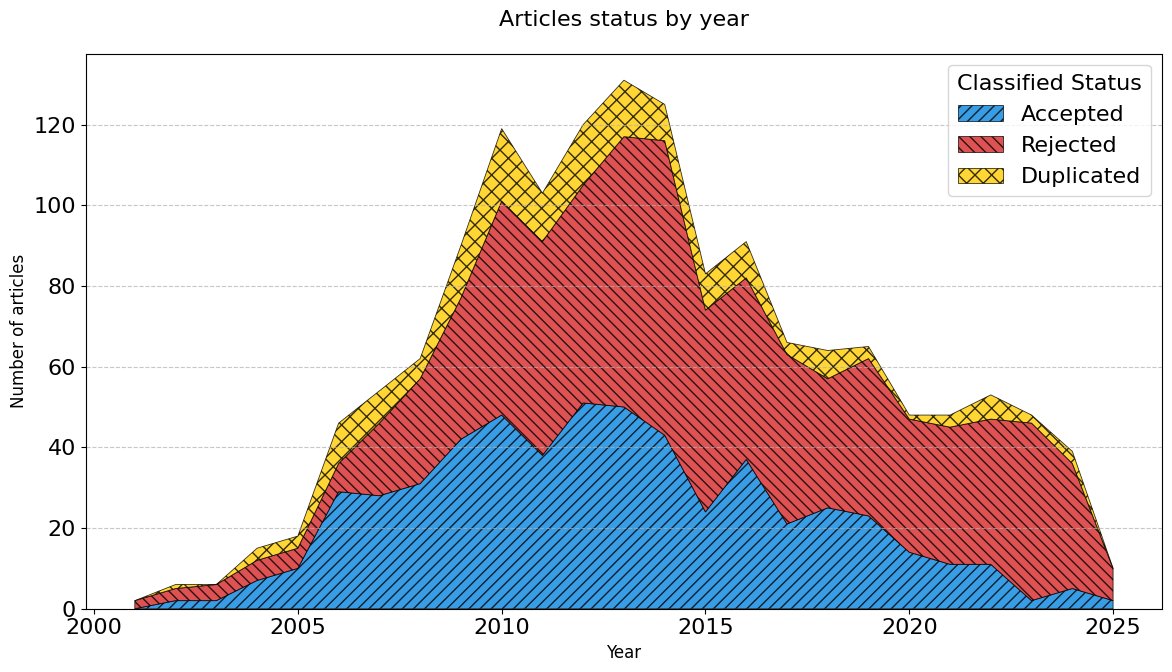

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 16})

def get_status_color(status):
    return {
        'Accepted': '#0785df',
        'Rejected': '#d62728',
        'Duplicated': '#ffcc00',
    }.get(status, '#999999')

articles_df = pd.read_csv('input/articles.csv')

articles_df = articles_df.dropna(subset=['year']).copy()
articles_df['year'] = articles_df['year'].astype(int)
articles_df = articles_df[articles_df['year'] != 1983].copy() # Removendo outlier de 1983

status_by_year = articles_df.pivot_table(index='year', columns='status', aggfunc='size', fill_value=0)
for status in ['Accepted', 'Rejected', 'Duplicated']:
    if status not in status_by_year.columns:
        status_by_year[status] = 0

labels = ['Accepted', 'Rejected', 'Duplicated']
status_by_year = status_by_year[labels]

fig, ax = plt.subplots(figsize=(12, 7))
status_by_year.plot.area(
    ax=ax,
    color=[get_status_color(s) for s in labels],
    alpha=0.8,
    linewidth=0,
)

hatches = ['///', '\\\\\\', 'xx']
for poly, hatch in zip(ax.collections, hatches):
    poly.set_hatch(hatch)
    poly.set_edgecolor('black')
    poly.set_linewidth(0.6)

ax.set_title('Articles status by year', fontsize=16, pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of articles', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.legend(title='Classified Status')

plt.tight_layout()
plt.savefig('figures/status_distribution_over_years_stacked_area.png', dpi=300)
plt.show()

## Razões de aceite por ano

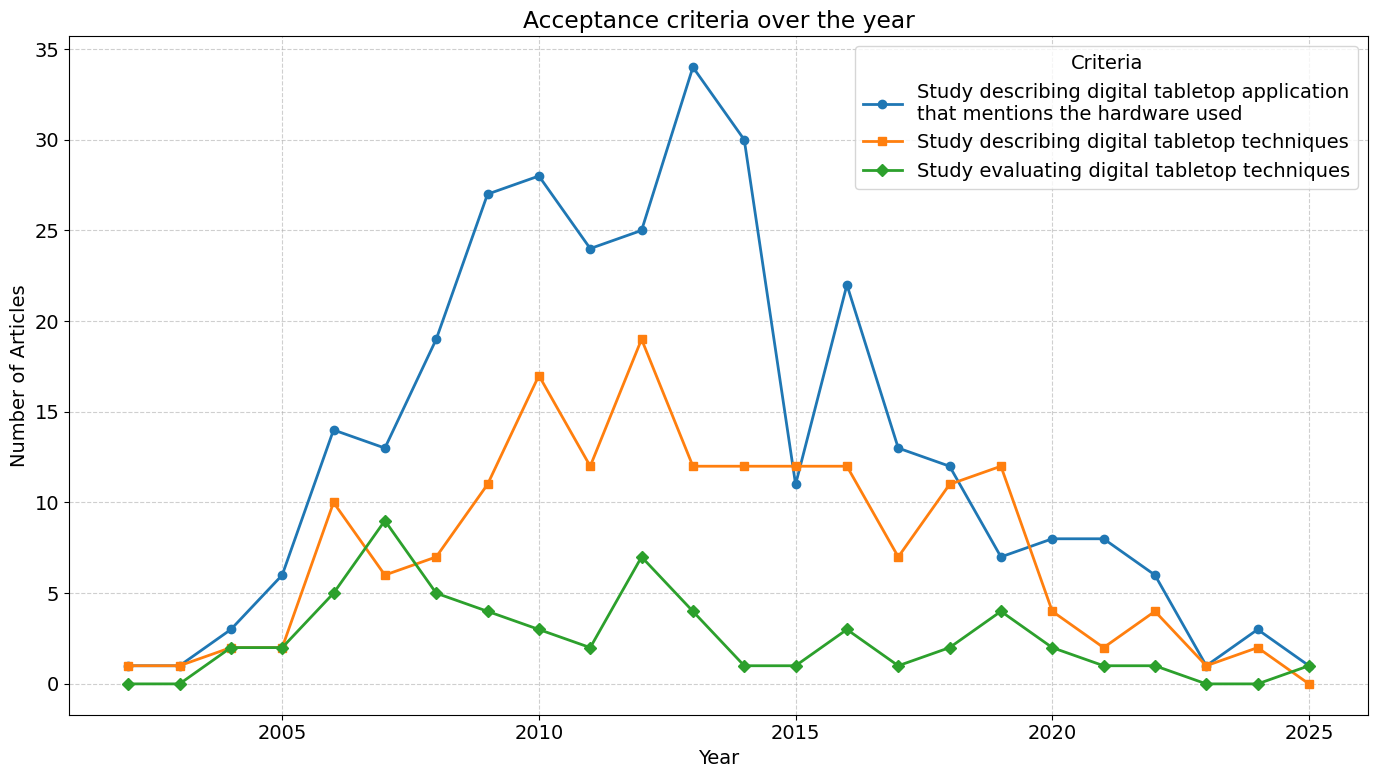

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

INPUT_CSV = 'transformed_data.csv'
OUTPUT_PNG = 'figures/line_chart_criteria_over_time.png'

def prepare_data(path):
    df = pd.read_csv(path)
    df = df[(df['status'] == 'Accepted') & (df['ano'].notna())].copy()
    df['ano'] = df['ano'].astype(int)
    return df.pivot_table(
        index='ano',
        columns='selection_criteria',
        aggfunc='size',
        fill_value=0,
    )

def plot_criteria_over_time(criteria_over_time, output_path):
    fig, ax = plt.subplots(figsize=(14, 8))

    cmap = plt.get_cmap('tab10')
    markers = ['o', 's', 'D', '^', 'v', 'P', 'X', '*']

    for i, criteria in enumerate(criteria_over_time.columns):
        wrapped_label = textwrap.fill(criteria, width=45)

        ax.plot(
            criteria_over_time.index,
            criteria_over_time[criteria],
            label=wrapped_label,
            color=cmap(i % 10),
            linewidth=2,
            marker=markers[i % len(markers)],
            markersize=6,
        )

    ax.set_title('Acceptance criteria over the year')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Articles')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(title='Criteria', loc='upper right')
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

criteria = prepare_data(INPUT_CSV)
plot_criteria_over_time(criteria, OUTPUT_PNG)

## Tecnologias de Display por ano

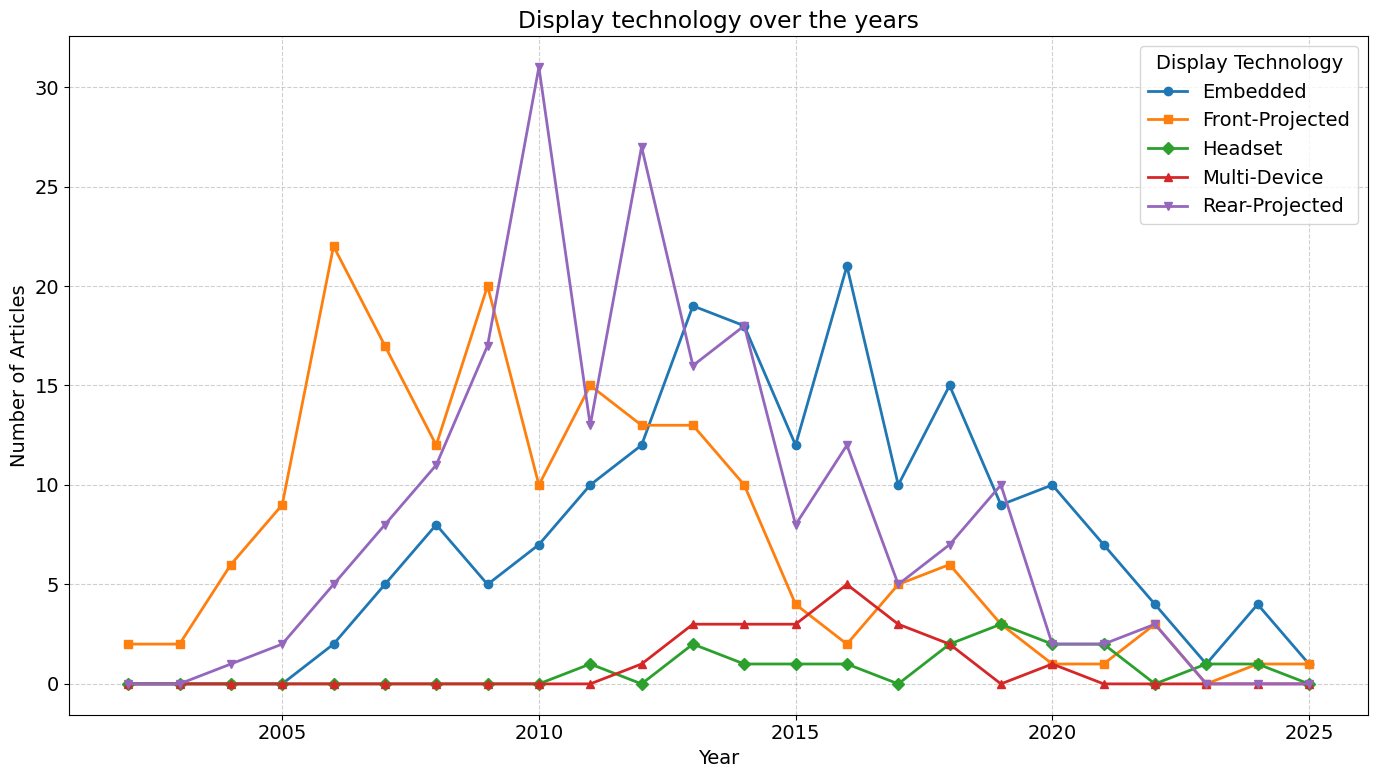

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

INPUT_CSV = 'accepted_data_adapted.csv'
OUTPUT_PNG = 'figures/display_tecnology_over_time.png'

df = pd.read_csv(INPUT_CSV)
df = df.dropna(subset=['ano', 'Tecnologia do display']).copy()
df['ano'] = df['ano'].astype(int)

df['Tecnologia do display'] = df['Tecnologia do display'].str.split(',')
df = df.explode('Tecnologia do display')
df['Tecnologia do display'] = df['Tecnologia do display'].str.strip()

timeline = (
    df.groupby(['ano', 'Tecnologia do display'])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 8))
cmap = plt.get_cmap('tab10')
markers = ['o', 's', 'D', '^', 'v', 'P', 'X', '*']

for i, tech in enumerate(timeline.columns):
    ax.plot(
        timeline.index,
        timeline[tech],
        label=tech,
        color=cmap(i % 10),
        marker=markers[i % len(markers)],
        linewidth=2,
        markersize=6,
    )

ax.set_title('Display technology over the years')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Articles')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title='Display Technology', loc='upper right')

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches='tight')
plt.show()

## Input por ano

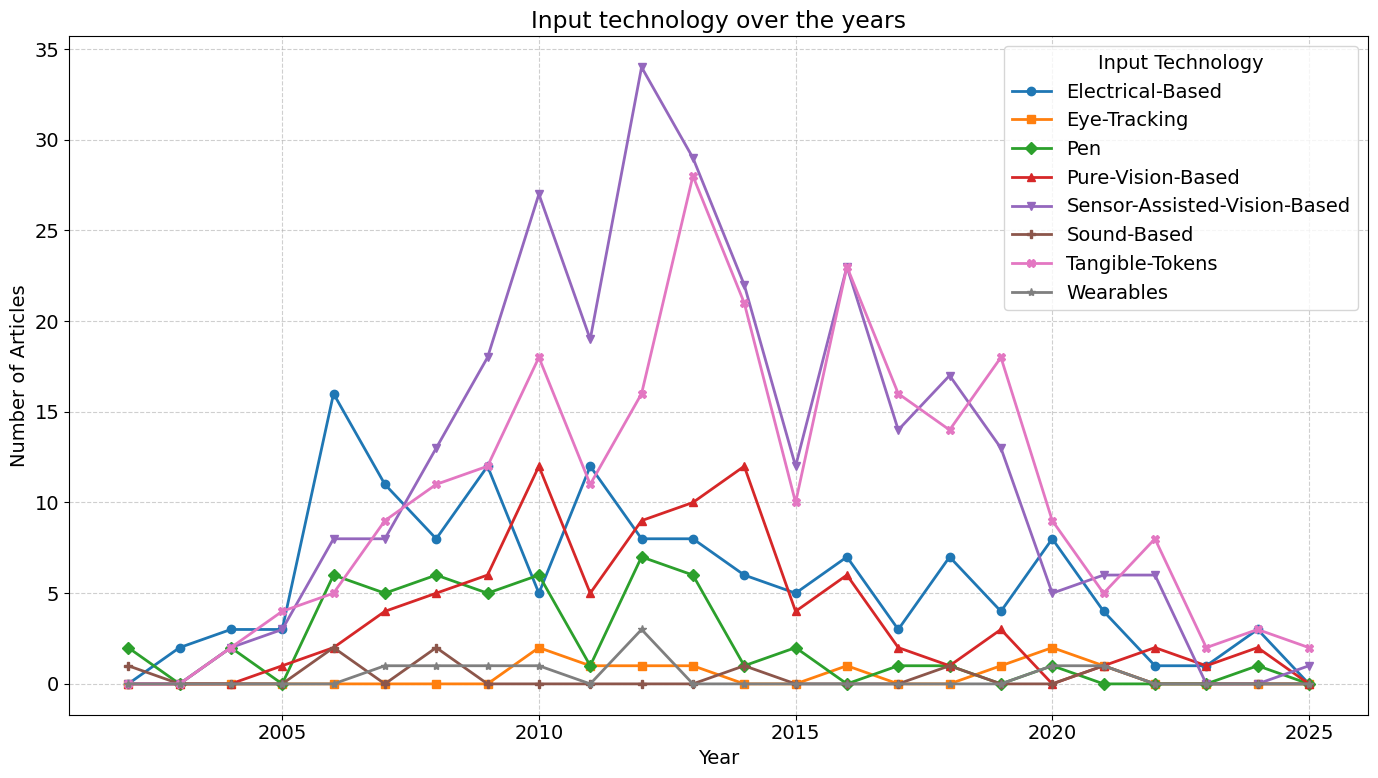

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

INPUT_CSV = 'accepted_data_adapted.csv'
OUTPUT_PNG = 'figures/input_tecnology_over_time.png'

df = pd.read_csv(INPUT_CSV)
df = df.dropna(subset=['ano', 'Tecnologia do input']).copy()
df['ano'] = df['ano'].astype(int)

df['Tecnologia do input'] = df['Tecnologia do input'].str.split(',')
df = df.explode('Tecnologia do input')
df['Tecnologia do input'] = df['Tecnologia do input'].str.strip()

timeline = (
    df.groupby(['ano', 'Tecnologia do input'])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 8))
cmap = plt.get_cmap('tab10')
markers = ['o', 's', 'D', '^', 'v', 'P', 'X', '*']

for i, tech in enumerate(timeline.columns):
    ax.plot(
        timeline.index,
        timeline[tech],
        label=tech,
        color=cmap(i % 10),
        marker=markers[i % len(markers)],
        linewidth=2,
        markersize=6,
    )

ax.set_title('Input technology over the years')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Articles')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title='Input Technology', loc='upper right')

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches='tight')
plt.show()

## Suporte a interação ao longo dos anos

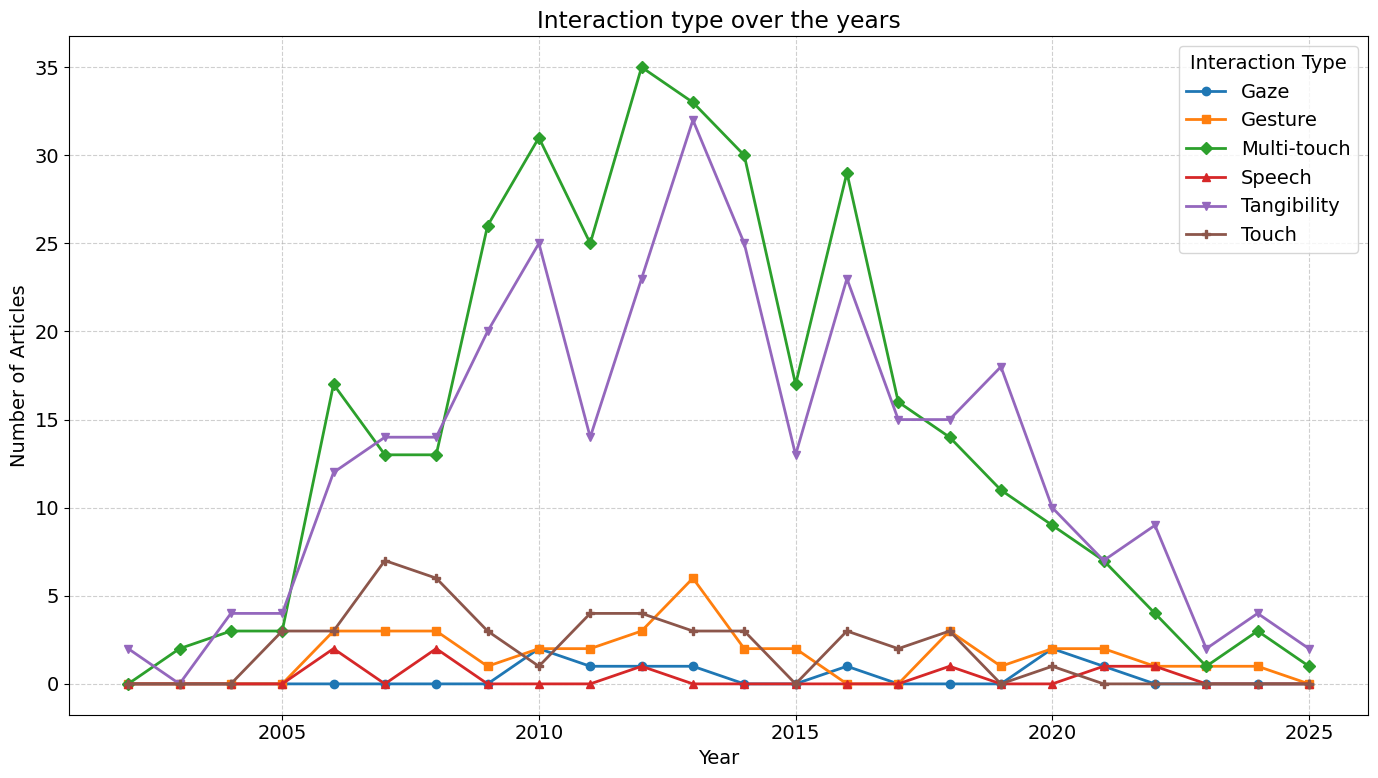

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

INPUT_CSV = 'accepted_data_adapted.csv'
OUTPUT_PNG = 'figures/interaction_support_over_time.png'

df = pd.read_csv(INPUT_CSV)
df = df.dropna(subset=['ano', 'Tipo de interação']).copy()
df['ano'] = df['ano'].astype(int)

df['Tipo de interação'] = df['Tipo de interação'].str.split(',')
df = df.explode('Tipo de interação')
df['Tipo de interação'] = df['Tipo de interação'].str.strip()

timeline = (
    df.groupby(['ano', 'Tipo de interação'])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 8))
cmap = plt.get_cmap('tab10')
markers = ['o', 's', 'D', '^', 'v', 'P', 'X', '*']

for i, interaction in enumerate(timeline.columns):
    ax.plot(
        timeline.index,
        timeline[interaction],
        label=interaction,
        color=cmap(i % 10),
        marker=markers[i % len(markers)],
        linewidth=2,
        markersize=6,
    )

ax.set_title('Interaction type over the years')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Articles')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title='Interaction Type', loc='upper right')

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches='tight')
plt.show()

## Colaboração


--- Análise de Suporte à Colaboração ---

Número de ocorrências por tipo de colaboração:
Suporte à colaboração
Co-located collaboration    467
Single user                  79
Remote collaboration         11
Name: count, dtype: int64

Percentagem de ocorrências por tipo de colaboração:
Suporte à colaboração
Co-located collaboration    83.84
Single user                 14.18
Remote collaboration         1.97
Name: count, dtype: float64
------------------------------------------


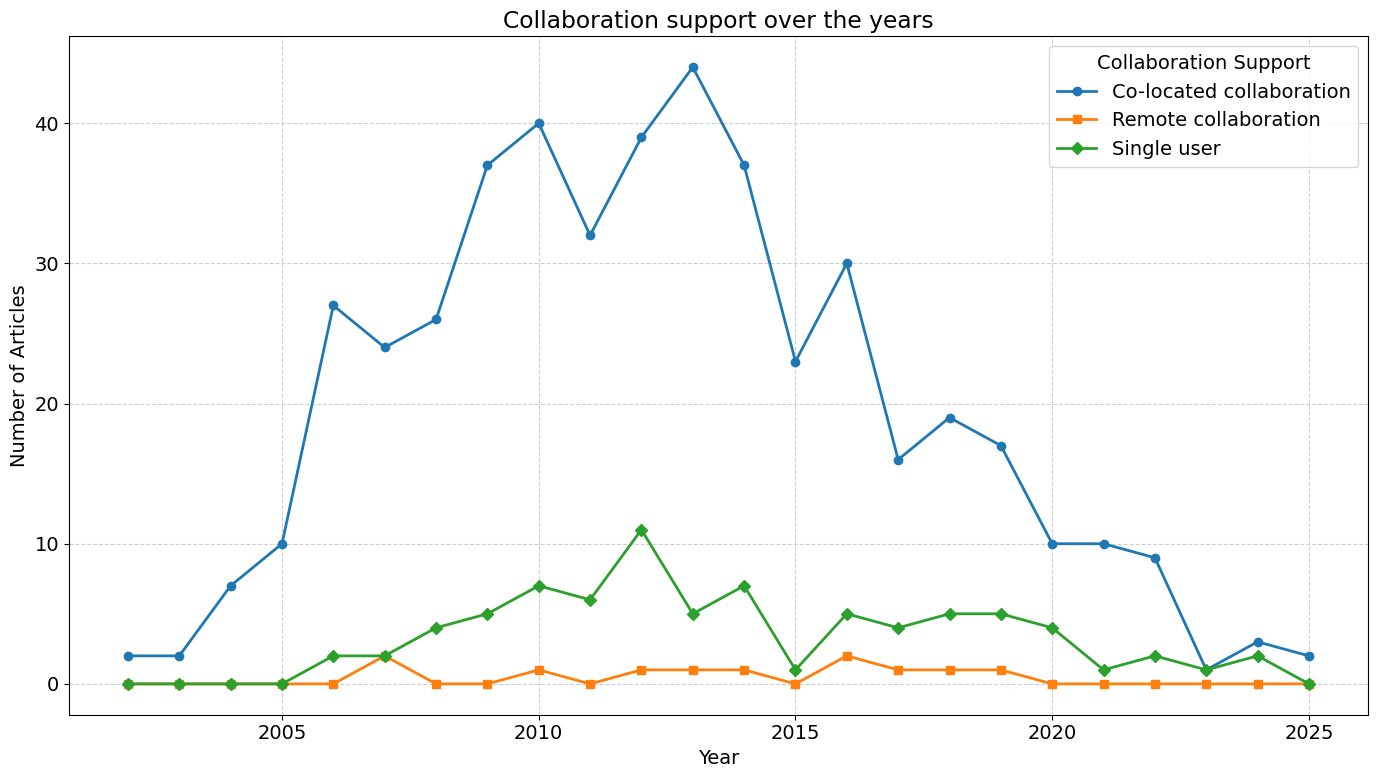

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

INPUT_CSV = 'accepted_data_adapted.csv'
OUTPUT_PNG = 'figures/collaboration_support_over_time.png'

df = pd.read_csv(INPUT_CSV)
df = df.dropna(subset=['ano', 'Suporte à colaboração']).copy()
df['ano'] = df['ano'].astype(int)

df['Suporte à colaboração'] = df['Suporte à colaboração'].str.split(',')
df = df.explode('Suporte à colaboração')
df['Suporte à colaboração'] = df['Suporte à colaboração'].str.strip()

df['Suporte à colaboração'] = df['Suporte à colaboração'].replace({
    'Colaboração presencial': 'Co-located collaboration',
    'Usuário único': 'Single user',
    'Colaboração remota': 'Remote collaboration',
})

print('\n--- Análise de Suporte à Colaboração ---')
collaboration_counts = df['Suporte à colaboração'].value_counts()
print('\nNúmero de ocorrências por tipo de colaboração:')
print(collaboration_counts)
print('\nPercentagem de ocorrências por tipo de colaboração:')
print(((collaboration_counts / collaboration_counts.sum()) * 100).round(2))
print('------------------------------------------')

timeline = (
    df.groupby(['ano', 'Suporte à colaboração'])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 8))
cmap = plt.get_cmap('tab10')
markers = ['o', 's', 'D', '^', 'v', 'P', 'X', '*']

for i, collaboration in enumerate(timeline.columns):
    ax.plot(
        timeline.index,
        timeline[collaboration],
        label=collaboration,
        color=cmap(i % 10),
        marker=markers[i % len(markers)],
        linewidth=2,
        markersize=6,
    )

ax.set_title('Collaboration support over the years')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Articles')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title='Collaboration Support', loc='upper right')

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches='tight')
plt.show()

## Modelos específicos

Número de artigos que mencionaram o modelo da mesa: 278

-------------------------------------


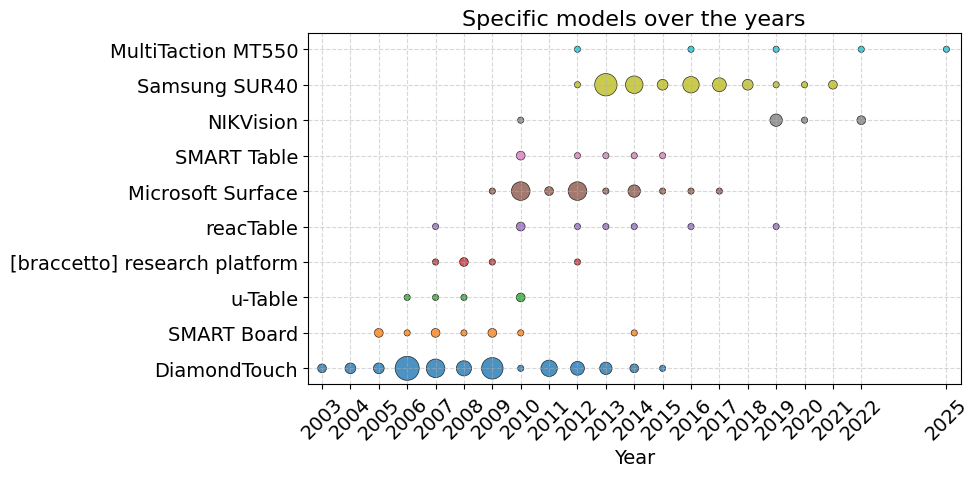

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

INPUT_CSV = 'accepted_data_adapted.csv'
OUTPUT_PNG = 'figures/models_over_time.png'

df = pd.read_csv(INPUT_CSV)
df['ano'] = pd.to_numeric(df['ano'], errors='coerce')
df = df.dropna(subset=['ano']).copy()
df['ano'] = df['ano'].astype(int)

df_modelos = df.dropna(subset=['Usa modelo com nome?']).copy()
print(f"Número de artigos que mencionaram o modelo da mesa: {len(df_modelos)}")
print('\n-------------------------------------')

df_modelos['Usa modelo com nome?'] = (
    df_modelos['Usa modelo com nome?']
    .str.split('+', n=1)
    .str[0]
    .str.strip()
)

modelo_por_ano = df_modelos.groupby(['Usa modelo com nome?', 'ano']).size().reset_index(name='count')
modelo_total = modelo_por_ano.groupby('Usa modelo com nome?')['count'].sum()
modelos_filtrados = modelo_total[modelo_total > 4].index
modelo_por_ano_filtrado = modelo_por_ano[modelo_por_ano['Usa modelo com nome?'].isin(modelos_filtrados)].copy()

ordem_modelos = (
    modelo_por_ano_filtrado
    .groupby('Usa modelo com nome?')['ano']
    .min()
    .sort_values()
    .index.tolist()
)

modelo_por_ano_filtrado['Usa modelo com nome?'] = pd.Categorical(
    modelo_por_ano_filtrado['Usa modelo com nome?'],
    categories=ordem_modelos,
    ordered=True,
)

fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.get_cmap('tab10')

for i, model in enumerate(ordem_modelos):
    subset = modelo_por_ano_filtrado[modelo_por_ano_filtrado['Usa modelo com nome?'] == model]
    if subset.empty:
        continue
    ax.scatter(
        subset['ano'],
        subset['Usa modelo com nome?'],
        s=subset['count'] * 20,
        color=cmap(i % 10),
        alpha=0.8,
        edgecolors='black',
        linewidths=0.5,
    )

ax.set_title('Specific models over the years', fontsize=16)
ax.set_xlabel('Year')
ax.set_ylabel('')
ax.grid(True, linestyle='--', alpha=0.5)

xticks = sorted(modelo_por_ano_filtrado['ano'].unique())
ax.set_xticks(xticks)
for label in ax.get_xticklabels():
    label.set_rotation(45)

if xticks:
    ax.set_xlim(min(xticks) - 0.5, max(xticks) + 0.5)

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=300)
plt.show()

## Tamanho da tela

Número de artigos que mencionaram o tamanho da mesa: 276

-------------------------------------
Maior tamanho encontrado: 169

--- Estatísticas de Tamanho da Mesa ---

5 tamanhos mais comuns:
Tamanho da mesa
42    84
40    48
30    34
55    23
46    18
Name: count, dtype: int64

Média de tamanho: 45.82 polegadas
Mediana de tamanho: 42.00 polegadas

-------------------------------------


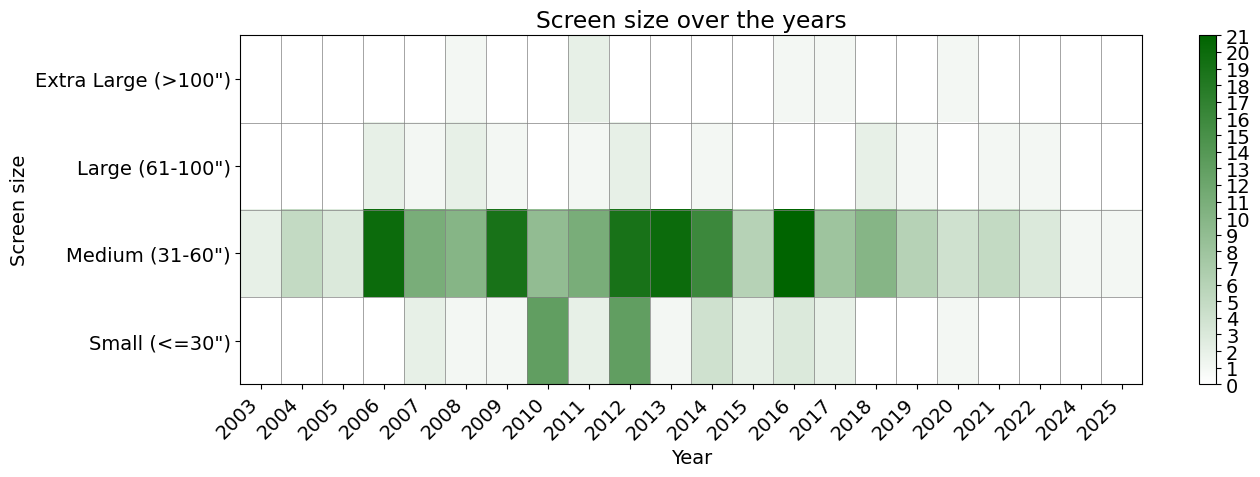

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({'font.size': 14})

INPUT_CSV = 'transformed_data.csv'
OUTPUT_PNG = 'figures/display_size_over_time.png'

df = pd.read_csv(INPUT_CSV)
df = df.dropna(subset=['ano', 'Tamanho da mesa']).copy()
df['ano'] = df['ano'].astype(int)
df['Tamanho da mesa'] = df['Tamanho da mesa'].str.replace(r'[\"]|[”’’″]', '', regex=True).str.strip()
df['Tamanho da mesa'] = pd.to_numeric(df['Tamanho da mesa'])
df = df.dropna(subset=['Tamanho da mesa'])

print(f"Número de artigos que mencionaram o tamanho da mesa: {len(df)}")
print('\n-------------------------------------')

df['Tamanho da mesa'] = df['Tamanho da mesa'].round(0).astype(int)
print('Maior tamanho encontrado:', df['Tamanho da mesa'].max())
print('\n--- Estatísticas de Tamanho da Mesa ---')
print('\n5 tamanhos mais comuns:')
print(df['Tamanho da mesa'].value_counts().head(5))
print(f"\nMédia de tamanho: {df['Tamanho da mesa'].mean():.2f} polegadas")
print(f"Mediana de tamanho: {df['Tamanho da mesa'].median():.2f} polegadas")
print('\n-------------------------------------')

def categorizar_tamanho(t):
    if t <= 30:
        return 'Small (<=30")'
    if t <= 60:
        return 'Medium (31-60")'
    if t <= 100:
        return 'Large (61-100")'
    return 'Extra Large (>100")'

df['Faixa de Tamanho'] = df['Tamanho da mesa'].apply(categorizar_tamanho)
faixa_heatmap = df.groupby(['Faixa de Tamanho', 'ano']).size().unstack(fill_value=0)
faixa_heatmap = faixa_heatmap.reindex(
    index=['Extra Large (>100")', 'Large (61-100")', 'Medium (31-60")', 'Small (<=30")'],
    fill_value=0,
)

cmap_branco_verde = LinearSegmentedColormap.from_list('branco_verde', ['#ffffff', '#006400'])

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(
    faixa_heatmap.values,
    cmap=cmap_branco_verde,
    aspect='auto',
    interpolation='nearest',
)

ax.set_title('Screen size over the years')
ax.set_xlabel('Year')
ax.set_ylabel('Screen size')
ax.set_xticks(np.arange(len(faixa_heatmap.columns)))
ax.set_xticklabels(faixa_heatmap.columns, rotation=45, ha='right')
ax.set_yticks(np.arange(len(faixa_heatmap.index)))
ax.set_yticklabels(faixa_heatmap.index)

cbar = fig.colorbar(im, ax=ax)
cbar.set_ticks(np.arange(0, faixa_heatmap.values.max() + 1))

ax.set_xticks(np.arange(-0.5, len(faixa_heatmap.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(faixa_heatmap.index), 1), minor=True)
ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
ax.tick_params(which='minor', bottom=False, left=False)

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=300)
plt.show()